In [25]:
import pandas as pd
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
with open("../wandb_aug_exps/results.json") as f:
    data = json.load(f)

In [27]:
df = pd.concat({
    model: pd.concat({
        dataset: pd.DataFrame(result).T 
        for dataset, result in datasets.items()
    })
    for model, datasets in data.items()
})

In [28]:
df

decision_accuracy  decision_f1  \
DeepSeek-V3-0324   banking77_ru 0            0.312987     0.344555   
                                1            0.360065     0.355973   
                                2            0.373701     0.370967   
                                3            0.378571     0.367369   
                                4            0.399675     0.396870   
...                                               ...          ...   
gpt-3.5-turbo-0125 clinc150_ru  7            0.292182     0.309371   
                                8            0.291636     0.313015   
                                9            0.301091     0.321455   
                                10           0.291818     0.311908   
                   banking77    0            0.759740     0.757067   

                                    decision_precision  decision_recall  \
DeepSeek-V3-0324   banking77_ru 0             0.445952         0.308974   
                                1             0.397241         0.360065   
                                2             0.407471         0.373701   
                                3             0.401386         0.378571   
                                4             0.431951         0.394551   
...                                                ...              ...   
gpt-3.5-turbo-0125 clinc150_ru  7             0.332286         0.354746   
                                8             0.344377         0.354084   
                                9             0.341007         0.365563   
                                10            0.337354         0.354305   
                   banking77    0             0.783371         0.750000   

                                    decision_roc_auc  
DeepSeek-V3-0324   banking77_ru 0           0.653603  
                                1           0.675822  
                                2           0.682730  
                                3           0.685197  
                                4           0.695980  
...                                              ...  
gpt-3.5-turbo-0125 clinc150_ru  7           0.675016  
                                8           0.674684  
                                9           0.680454  
                                10          0.674794  
                   banking77    0           0.878426  

[245 rows x 5 columns]

/tmp/ipykernel_80297/644680940.py:24: PerformanceWarning: indexing past lexsort depth may impact performance.
  sub = df.loc[(model, dataset)]


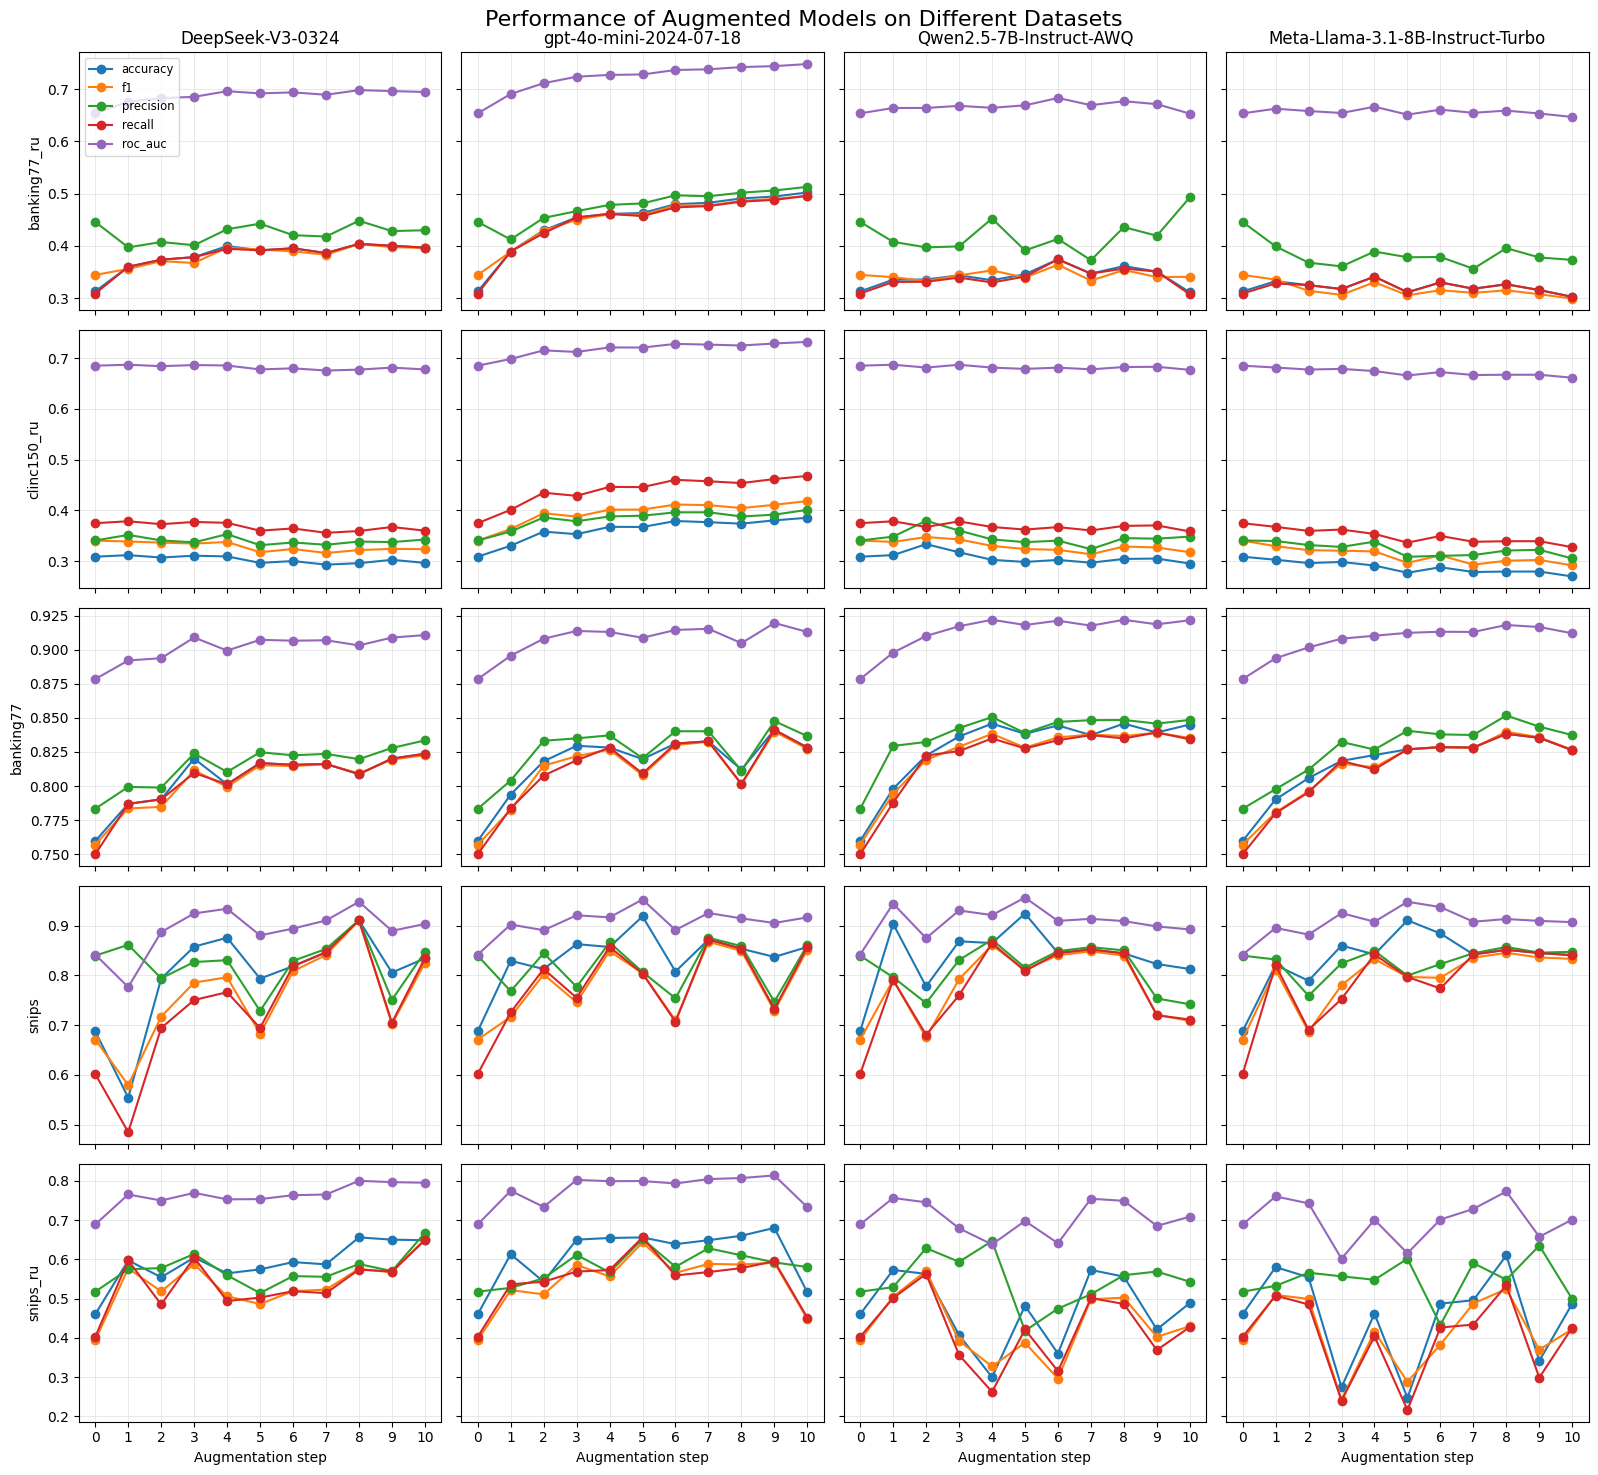

In [34]:
models  = df.index.get_level_values(0).unique()
datasets= df.index.get_level_values(1).unique()
metrics = df.columns

for model in models:
    if model in ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3-8B-Instruct", "gpt-3.5-turbo-0125"]:
        models = models.drop(model)


# make sure we always have a 2D axes array
fig, axes = plt.subplots(
    nrows=len(datasets),
    ncols=len(models),
    figsize=(4*len(models), 3*len(datasets)),
    sharex=True,
    sharey='row',
)
axes = np.atleast_2d(axes)

for i, dataset in enumerate(datasets):
    for j, model in enumerate(models):
        ax = axes[i, j]
        try:
            sub = df.loc[(model, dataset)]
        except KeyError:
            print(f"Skipping {model} on {dataset} as no data is available.")
            continue
        for metric in metrics:
            ax.plot(sub.index, sub[metric], marker='o', label=metric.replace("decision_", ""))
        if i == len(datasets)-1:
            ax.set_xlabel("Augmentation step")
        if j == 0:
            ax.set_ylabel(dataset)
        if i == 0:
            ax.set_title(model)
        if i == 0 and j == 0:
            ax.legend(loc="upper left", fontsize="small")
        ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
plt.suptitle("Performance of Augmented Models on Different Datasets", fontsize=16)
plt.tight_layout()
plt.savefig("augmented_models_performance.png", dpi=300)
plt.savefig("augmented_models_performance.svg")
plt.show()

Index(['DeepSeek-V3-0324', 'gpt-4o-mini-2024-07-18', 'Qwen2.5-7B-Instruct-AWQ',
       'Meta-Llama-3-8B-Instruct', 'Meta-Llama-3.1-8B-Instruct',
       'Meta-Llama-3.1-8B-Instruct-Turbo', 'gpt-3.5-turbo-0125'],
      dtype='object')